# Exercice 2.2 : Détection de Densité (DBSCAN)
Dans cet atelier, nous explorons le clustering par densité avec DBSCAN.

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy().sample(frac=0.1, random_state=42)  # Échantillon de 10% pour accélérer le traitement
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))

X_scaled = features

X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
print("Données prêtes :", X_scaled.shape)

Données prêtes : (8233, 45)


Points classés comme bruit (-1, outliers) : 8233 flux (100.0%)


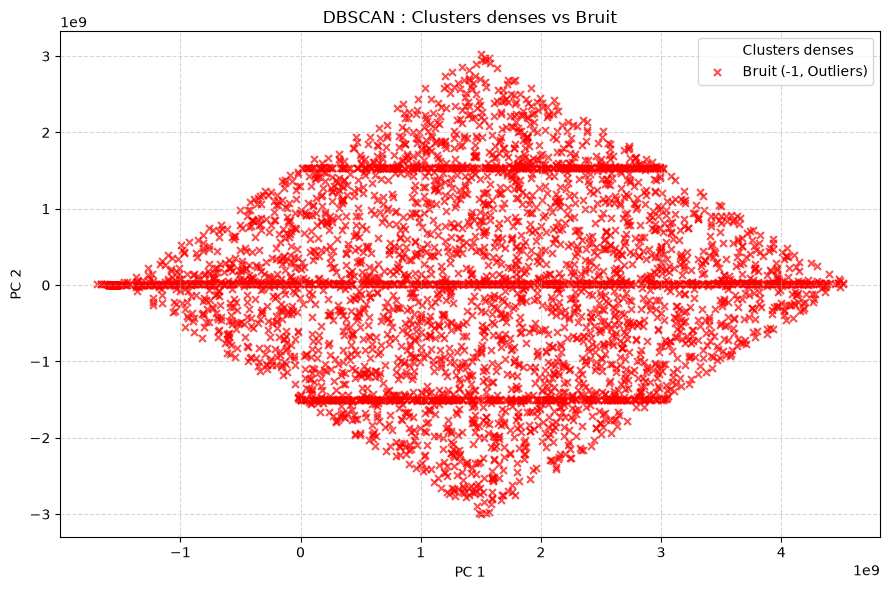

In [6]:
from sklearn.cluster import DBSCAN
from helper import plot_dbscan_scatter

eps = 2
min_samples = 15

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
n_bruit = (db.labels_ == -1).sum()
print(f"Points classés comme bruit (-1, outliers) : {n_bruit} flux ({n_bruit/len(X_scaled)*100:.1f}%)")

plot_dbscan_scatter(X_2d, db.labels_)